In [1]:
import os, sys,json
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
REPO = '/home/mantovani/repo/generalize_knowledge'
os.chdir(REPO)                    # so 'data/...' paths also resolve
sys.path.insert(0, f'{REPO}/src')
import yaml, glob, sweep 
cfg = yaml.safe_load(open('experiments/exp01.yaml'))
# point at the sweep results you want to watch:
TAG='facts_attr'; RUN='train_qa_forward-declarative_en'; FOLD=0
RESULTS=f'data/results/{TAG}/{RUN}/sweep_fold{FOLD}'
print('watching:', RESULTS)


watching: data/results/facts_attr/train_qa_forward-declarative_en/sweep_fold0


In [2]:
# ===== progress: how many of the expected runs are done =====
from transformers import AutoConfig
snap=os.path.join(cfg['models']['target'],'snapshots')
mp=os.path.join(snap,os.listdir(snap)[0]) if os.path.isdir(snap) else cfg['models']['target']
nL=AutoConfig.from_pretrained(mp).num_hidden_layers
done=glob.glob(f'{RESULTS}/runs/*/summary.json')
evald=[p for p in done if os.path.isdir(os.path.join(os.path.dirname(p),'evaluated'))]
print(f'configs per seed = {nL+2} (all + {nL} singles + base)')
print(f'trained: {len(done)}   evaluated: {len(evald)}')


configs per seed = 34 (all + 32 singles + base)
trained: 13   evaluated: 13


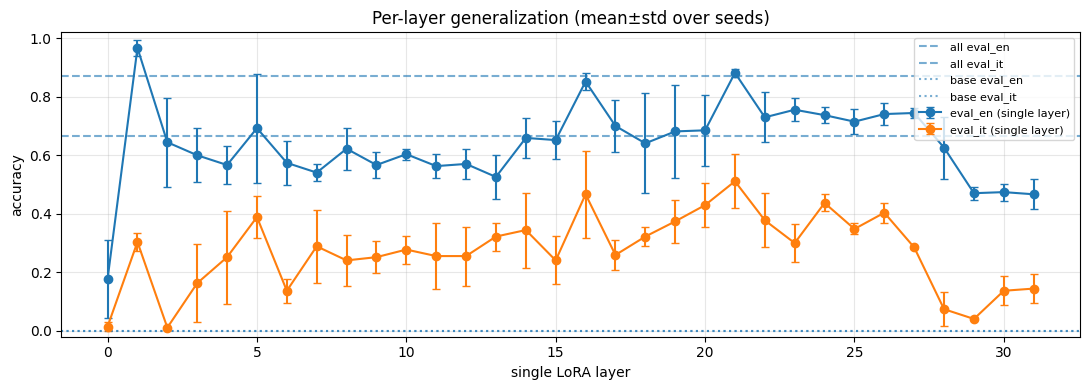

102 runs on disk  (seeds done: [0, 1, 2])


In [8]:
# ===== THE PLOT: upper bound (all), base, and each single layer (mean±std over seeds) =====
# re-run this cell anytime while run.py is training to watch it fill in
import importlib; importlib.reload(sweep)
sweep.plot_sweep(RESULTS)


In [9]:
# ===== optional: results table =====
recs=[json.load(open(p)) for p in glob.glob(f'{RESULTS}/runs/*/summary.json')]
tiers=sorted({k for r in recs for k in r if k.startswith('eval_')})
from collections import defaultdict
import statistics as st
agg=defaultdict(lambda: defaultdict(list))
for r in recs:
    key=r['layers']
    for t in tiers:
        if r.get(t) is not None: agg[key][t].append(r[t])
def order(k):
    return -1 if k=='all' else 999 if k=='base' else int(k[1:])
print('config   ' + '  '.join(f'{t:>10}' for t in tiers))
for k in sorted(agg, key=order):
    row=' '.join(f'{st.mean(agg[k][t]):.2f}±{(st.pstdev(agg[k][t]) if len(agg[k][t])>1 else 0):.2f}'
                 if agg[k][t] else '   -   ' for t in tiers)
    print(f'{k:8s} {row}')


config      eval_en     eval_it
all      0.87±0.09 0.67±0.17
L0       0.18±0.13 0.01±0.01
L1       0.97±0.03 0.30±0.03
L2       0.64±0.15 0.01±0.00
L3       0.60±0.09 0.16±0.13
L4       0.57±0.07 0.25±0.16
L5       0.69±0.19 0.39±0.07
L6       0.57±0.08 0.14±0.04
L7       0.54±0.03 0.29±0.13
L8       0.62±0.07 0.24±0.09
L9       0.57±0.05 0.25±0.05
L10      0.60±0.02 0.28±0.05
L11      0.56±0.04 0.26±0.11
L12      0.57±0.05 0.26±0.10
L13      0.53±0.07 0.32±0.05
L14      0.66±0.07 0.34±0.13
L15      0.65±0.07 0.24±0.08
L16      0.85±0.03 0.47±0.15
L17      0.70±0.09 0.26±0.05
L18      0.64±0.17 0.32±0.03
L19      0.68±0.16 0.37±0.07
L20      0.69±0.12 0.43±0.08
L21      0.88±0.01 0.51±0.09
L22      0.73±0.09 0.38±0.09
L23      0.76±0.04 0.30±0.06
L24      0.74±0.03 0.44±0.03
L25      0.71±0.04 0.35±0.02
L26      0.74±0.04 0.40±0.03
L27      0.74±0.02 0.29±0.01
L28      0.63±0.11 0.07±0.06
L29      0.47±0.02 0.04±0.01
L30      0.47±0.03 0.14±0.05
L31      0.47±0.05 0.14±0.05
base     0.